In [1]:
import pandas as pd
import numpy as np
import sklearn
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 3.0.5
numpy: 2.5.3
scikit-learn: 1.9.1


# 01 — Data Exploration

**Goal:** Load the cleaned sorting and searching datasets, verify their shape and
integrity, and document any data-quality issues before feature engineering begins.

This notebook checks for:
- Missing values
- Duplicate rows
- Impossible/out-of-range values
- Class balance across algorithms and data types
- Execution-time distribution and potential anomalies

No cleaning decisions are made here beyond what `data_cleaning.py` already does —
this is purely diagnostic.

In [3]:
import pandas as pd

sorting_df = pd.read_csv("../data/processed/sorting_clean.csv")
searching_df = pd.read_csv("../data/processed/searching_clean.csv")

print("Sorting dataset shape:", sorting_df.shape)
print("Searching dataset shape:", searching_df.shape)

Sorting dataset shape: (34992, 11)
Searching dataset shape: (29788, 10)


In [4]:
sorting_df.head()

searching_df.head()

,algorithm,input_size,case_type,trial_id,probes,time_taken,memory_used,found,load_factor,collision_count
0,linear_search,10,best_case,1,4,0.000035,416,True,NaN,NaN
1,binary_search,10,best_case,1,3,0.000032,416,True,NaN,NaN
2,interpolation_search,10,best_case,1,2,0.000027,416,True,NaN,NaN
3,exponential_search,10,best_case,1,8,0.000042,416,True,NaN,NaN
4,fibonacci_search,10,best_case,1,3,0.000020,416,True,NaN,NaN


In [5]:
sorting_df.info()
searching_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34992 entries, 0 to 34991
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   algorithm            34992 non-null  str    
 1   input_size           34992 non-null  int64  
 2   data_type            34992 non-null  str    
 3   trial_id             34992 non-null  int64  
 4   comparisons          34992 non-null  int64  
 5   swaps                34992 non-null  int64  
 6   time_taken           34992 non-null  float64
 7   memory_used          34992 non-null  int64  
 8   presortedness_score  34992 non-null  float64
 9   duplicate_ratio      34992 non-null  float64
 10  value_range          34992 non-null  int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 3.6 MB
<class 'pandas.DataFrame'>
RangeIndex: 29788 entries, 0 to 29787
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0  

In [6]:
sorting_df.describe()
searching_df.describe()

,input_size,trial_id,probes,time_taken,memory_used,load_factor,collision_count
count,29788.000000,29788.000000,29788.000000,29788.000000,29788.000000,5000.0,5000.000000
mean,1002.829999,2.999966,100.943333,0.000464,36157.879952,2.0,570.620600
std,577.386483,1.414202,294.308789,0.000546,20785.913404,0.0,328.001601
min,10.000000,1.000000,0.000000,0.000006,416.000000,2.0,5.000000
25%,500.000000,2.000000,3.000000,0.000142,18056.000000,2.0,287.000000
50%,1000.000000,3.000000,9.000000,0.000317,36056.000000,2.0,571.000000
75%,1500.000000,4.000000,18.000000,0.000506,54056.000000,2.0,855.000000
max,2000.000000,5.000000,2000.000000,0.006320,72056.000000,2.0,1153.000000


In [7]:
print("Sorting missing values:\n", sorting_df.isnull().sum())
print("\nSearching missing values:\n", searching_df.isnull().sum())

Sorting missing values:
 algorithm              0
input_size             0
data_type              0
trial_id               0
comparisons            0
swaps                  0
time_taken             0
memory_used            0
presortedness_score    0
duplicate_ratio        0
value_range            0
dtype: int64

Searching missing values:
 algorithm              0
input_size             0
case_type              0
trial_id               0
probes                 0
time_taken             0
memory_used            0
found                  0
load_factor        24788
collision_count    24788
dtype: int64


In [8]:
print("Sorting duplicate rows:", sorting_df.duplicated().sum())
print("Searching duplicate rows:", searching_df.duplicated().sum())


Sorting duplicate rows: 0
Searching duplicate rows: 0


In [9]:
print("Sorting algorithms:", sorted(sorting_df["algorithm"].unique()))
print("Sorting data_types:", sorted(sorting_df["data_type"].unique()))
print()
print("Searching algorithms:", sorted(searching_df["algorithm"].unique()))
print("Searching case_types:", sorted(searching_df["case_type"].unique()))

Sorting algorithms: ['bubble_sort', 'heap_sort', 'insertion_sort', 'merge_sort', 'quick_sort', 'radix_sort', 'selection_sort']
Sorting data_types: ['duplicates', 'nearly_sorted', 'random', 'reverse_sorted', 'sorted']

Searching algorithms: ['binary_search', 'exponential_search', 'fibonacci_search', 'hashing_search', 'interpolation_search', 'linear_search']
Searching case_types: ['average_case', 'best_case', 'duplicates_present', 'not_found', 'worst_case']


In [10]:
print("Sorting rows per algorithm:\n", sorting_df["algorithm"].value_counts())
print("\nSearching rows per algorithm:\n", searching_df["algorithm"].value_counts())


Sorting rows per algorithm:
 algorithm
merge_sort        5000
selection_sort    4999
quick_sort        4999
heap_sort         4999
radix_sort        4999
bubble_sort       4998
insertion_sort    4998
Name: count, dtype: int64

Searching rows per algorithm:
 algorithm
hashing_search          5000
exponential_search      4999
binary_search           4998
fibonacci_search        4998
interpolation_search    4997
linear_search           4796
Name: count, dtype: int64


In [11]:
print("Sorting time_taken range:", sorting_df["time_taken"].min(), "to", sorting_df["time_taken"].max())
print("Searching time_taken range:", searching_df["time_taken"].min(), "to", searching_df["time_taken"].max())

Sorting time_taken range: 4.900000931229442e-06 to 1.046819700000924
Searching time_taken range: 5.999998393235728e-06 to 0.00631969999813


In [12]:
sorting_df.nlargest(10, "time_taken")[["algorithm", "input_size", "data_type", "trial_id", "time_taken"]]

,algorithm,input_size,data_type,trial_id,time_taken
20936,bubble_sort,1990,reverse_sorted,2,1.046820
20887,bubble_sort,1970,reverse_sorted,5,1.019765
20957,bubble_sort,1990,reverse_sorted,5,1.011054
20796,bubble_sort,1950,reverse_sorted,2,0.993375
20775,bubble_sort,1940,reverse_sorted,4,0.978189
20866,bubble_sort,1970,reverse_sorted,2,0.972646
20705,bubble_sort,1920,reverse_sorted,4,0.966255
20810,bubble_sort,1950,reverse_sorted,4,0.957904
20649,bubble_sort,1910,reverse_sorted,1,0.950389
20971,bubble_sort,2000,reverse_sorted,2,0.949086


In [15]:
searching_df[searching_df["algorithm"] == "linear_search"]["case_type"].value_counts()
searching_df[searching_df["algorithm"] != "linear_search"].groupby("algorithm")["case_type"].value_counts()

print(searching_df[searching_df["algorithm"] == "linear_search"]["case_type"].value_counts())
print(searching_df[searching_df["algorithm"] == "binary_search"]["case_type"].value_counts())


case_type
not_found             999
average_case          954
duplicates_present    953
worst_case            949
best_case             941
Name: count, dtype: int64
case_type
worst_case            1000
not_found             1000
duplicates_present    1000
best_case              999
average_case           999
Name: count, dtype: int64


## Data Quality Findings

- **No missing values** in numeric/categorical fields for either dataset (except
  `load_factor`/`collision_count` in searching, which are only defined for
  `hashing_search` — expected, not a data quality issue).
- **No duplicate rows** in either dataset.
- **`load_factor` is constant (2.0)** across all hashing rows — zero variance,
  so it carries no predictive signal as a numeric feature. Will be documented
  and likely excluded from modeling (kept as descriptive metadata only).
- **Top time_taken outliers** are all `bubble_sort` on `reverse_sorted` data at
  large input sizes (1900–2000) — consistent with bubble sort's known O(n²)
  worst case, not a measurement error.
- **`linear_search` has slightly fewer rows** (4796 vs ~4998-5000 for other
  algorithms) due to higher trial-to-trial timing variance (target position
  varies), causing more trials to be caught by the median-ratio outlier filter.
  This is expected behavior, not a bug.

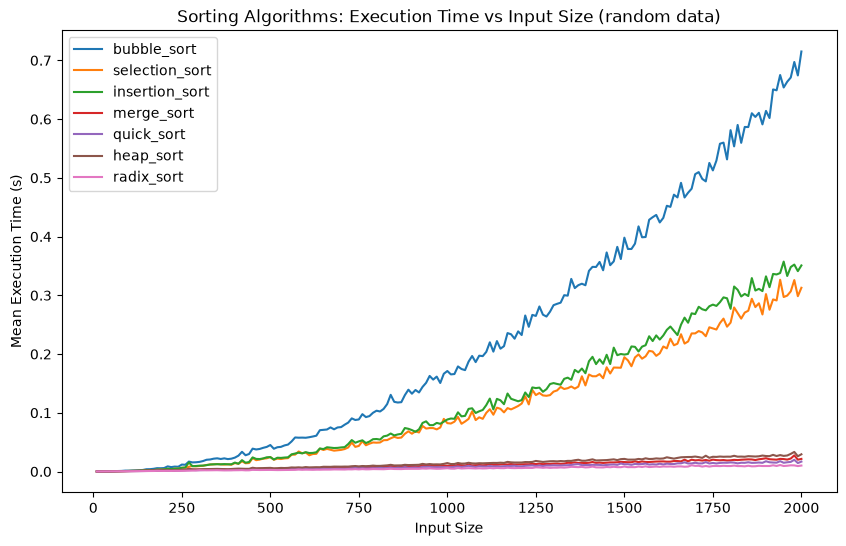

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for algo in sorting_df["algorithm"].unique():
    subset = sorting_df[(sorting_df["algorithm"] == algo) & (sorting_df["data_type"] == "random")]
    means = subset.groupby("input_size")["time_taken"].mean()
    ax.plot(means.index, means.values, label=algo)

ax.set_xlabel("Input Size")
ax.set_ylabel("Mean Execution Time (s)")
ax.set_title("Sorting Algorithms: Execution Time vs Input Size (random data)")
ax.legend()
plt.show()